# Social Media Trend Analysis Project

## Objective
Analyze social media tweets and identify sentiment trends using Python and NLP techniques.

## Technologies Used
- Python
- Pandas
- NLTK
- TextBlob
- Matplotlib

## Features
- Data Cleaning
- Stopword Removal
- Sentiment Analysis
- Polarity Scoring
- Visualization

In [5]:
import pandas as pd

df = pd.read_csv("training.csv", encoding='latin-1')

df.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [6]:
print(df.shape)

print(df.columns)

df.info()

(1599999, 6)
Index(['0', '1467810369', 'Mon Apr 06 22:19:45 PDT 2009', 'NO_QUERY',
       '_TheSpecialOne_',
       '@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 6 columns):
 #   Column                                                                                                               Non-Null Count    Dtype
---  ------                                                                                                               --------------    -----
 0   0                                                                                                                    1599999 non-null  int64
 1   1467810369                                                                                                           1599999 non-null  int64
 2   Mon Apr 06 22:19:45 PDT 2009                           

In [7]:
df.isnull().sum()

0                                                                                                                      0
1467810369                                                                                                             0
Mon Apr 06 22:19:45 PDT 2009                                                                                           0
NO_QUERY                                                                                                               0
_TheSpecialOne_                                                                                                        0
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D    0
dtype: int64

In [8]:
df.head(10)

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
5,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
6,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
7,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
8,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?
9,0,1467812416,Mon Apr 06 22:20:16 PDT 2009,NO_QUERY,erinx3leannexo,spring break in plain city... it's snowing


In [9]:
df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'tweet']

df.head()

,sentiment,id,date,query,user,tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [10]:
df[['sentiment', 'tweet']].head(10)

,sentiment,tweet
0,0,is upset that he can't update his Facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew
5,0,Need a hug
6,0,@LOLTrish hey long time no see! Yes.. Rains a...
7,0,@Tatiana_K nope they didn't have it
8,0,@twittera que me muera ?
9,0,spring break in plain city... it's snowing


In [11]:
df['sentiment'].value_counts()

sentiment
4    800000
0    799999
Name: count, dtype: int64

In [12]:
df = df[['sentiment', 'tweet']]

df.head()

,sentiment,tweet
0,0,is upset that he can't update his Facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew


In [13]:
df.shape


(1599999, 2)

In [14]:
df['sentiment'] = df['sentiment'].replace(4, 1)

df['sentiment'].value_counts()

sentiment
1    800000
0    799999
Name: count, dtype: int64

In [15]:
df.head()

,sentiment,tweet
0,0,is upset that he can't update his Facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew


In [16]:
df.tail()

,sentiment,tweet
1599994,1,Just woke up. Having no school is the best fee...
1599995,1,TheWDB.com - Very cool to hear old Walt interv...
1599996,1,Are you ready for your MoJo Makeover? Ask me f...
1599997,1,Happy 38th Birthday to my boo of alll time!!! ...
1599998,1,happy #charitytuesday @theNSPCC @SparksCharity...


In [17]:
import re
import string

In [18]:
def clean_tweet(text):
    
    text = text.lower()
    
    text = re.sub(r'http\\S+', '', text)
    
    text = re.sub(r'@\\w+', '', text)
    
    text = re.sub(r'#', '', text)
    
    text = re.sub(r'[^a-zA-Z\\s]', '', text)
    
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    return text

In [20]:
df['clean_tweet'] = df['tweet'].apply(clean_tweet)

df[['tweet', 'clean_tweet']].head()

,tweet,clean_tweet
0,is upset that he can't update his Facebook by ...,isupsetthathecantupdatehisfacebookbytextingita...
1,@Kenichan I dived many times for the ball. Man...,kenichanidivedmanytimesfortheballmanagedtosave...
2,my whole body feels itchy and like its on fire,mywholebodyfeelsitchyandlikeitsonfire
3,"@nationwideclass no, it's not behaving at all....",nationwideclassnoitsnotbehavingatallimmadwhyam...
4,@Kwesidei not the whole crew,kwesideinotthewholecrew


In [22]:
df[['tweet', 'clean_tweet']].sample(10)

,tweet,clean_tweet
1113977,"@FergusononFox Oh, just experiment with it &am...",fergusononfoxohjustexperimentwithitampyoullget...
1463944,tyson ritter - a perfect example that taking d...,tysonritteraperfectexamplethattakingdrugsisnot...
954880,Happy birthday Norway &lt;3 and what a day to ...,happybirthdaynorwayltandwhatadaytowineurovisio...
747414,Ever get in a mood where everything and everyo...,evergetinamoodwhereeverythingandeveryoneirrita...
995489,"@wyelin haha, congrats! now, we can anticipate...",wyelinhahacongratsnowwecananticipatemoreofnesd...
504773,Do I look professional enough for a bank inter...,doilookprofessionalenoughforabankinterviewhttp...
819749,"is at home, cleaning up the apt and getting re...",isathomecleaninguptheaptandgettingreadyforthee...
642237,Had a meeting with a person which I donÂ´t wan...,hadameetingwithapersonwhichidontwanttomeetatth...
716283,@polgara Same here want to swap places? Come ...,polgarasameherewanttoswapplacescometolondonalt...
1466491,@missmanalo horror movie. Hahah. It's a good o...,missmanalohorrormoviehahahitsagoodoneaccording...


In [23]:
def clean_tweet(text):
    
    text = text.lower()
    
    text = re.sub(r'http\\S+', '', text)
    
    text = re.sub(r'@\\w+', '', text)
    
    text = re.sub(r'#', '', text)
    
    text = re.sub(r'[^a-zA-Z\\s]', '', text)
    
    return text

In [25]:
def clean_tweet(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

In [26]:
df['clean_tweet'] = df['tweet'].apply(clean_tweet)

df[['tweet', 'clean_tweet']].sample(10)

,tweet,clean_tweet
834666,@Emmajones79 'nice one' it starts at 6 .. mee...,nice one it starts at meetin for predrinki...
152768,@boobsie_lu oh I sure would love to do that 2m...,oh i sure would love to do that moro lol but ...
14081,Good morning freight train. Good morning Twitt...,good morning freight train good morning twitte...
1594214,"@CobrokeNation Yes, you can put me on your sit...",yes you can put me on your site is there any...
1091532,sleeeeepin off the bzzzz. goood $h1t but I go...,sleeeeepin off the bzzzz goood ht but i gotta...
812313,I found this cool website called cuteashell.co...,i found this cool website called cuteashellcom...
1297018,"@elliebek YARGONNNNNNNNNN, and why do you not ...",yargonnnnnnnnnn and why do you not love chery...
1303826,"Finished Zoe mix on Sat, demo of a new track c...",finished zoe mix on sat demo of a new track ca...
257422,@stephen_daniel yes and all randomly too and i...,yes and all randomly too and it wont stop i u...
1395951,@contented_raine oh welcome then well I'm onl...,oh welcome then well im only following her s...


In [27]:
from nltk.corpus import stopwords
import nltk

In [28]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sonaw\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [29]:
stop_words = set(stopwords.words('english'))

print(stop_words)

{'hadn', "mightn't", 'than', "it'd", 'that', 'up', 'shouldn', "i'll", 'to', 'mightn', 'hasn', 'theirs', 'further', "i'm", "she'd", 'while', 'were', 'few', 'those', "should've", "you'd", 'his', "they're", 'how', 'my', 'which', 'such', 'but', 'more', 'these', "we'd", 'they', "they'll", 'into', 'her', 'll', 'having', "he's", 'just', "couldn't", 'needn', 'been', 'had', "you've", 'or', 'weren', 'ma', "she'll", 'once', 'haven', 'between', 'itself', 'from', 'do', 'out', 'shan', 'yours', 'each', 'their', 'why', 'yourself', 'mustn', "shan't", 'what', 'your', 'ours', 'can', 'all', 'at', 'hers', 'yourselves', 'nor', "we're", 'am', "you're", 'didn', 'as', 'against', "we've", 'down', 'me', 'through', "didn't", "that'll", 'about', "mustn't", 'be', 'our', "he'll", "we'll", 'is', 'whom', "it's", 'don', 'did', 'where', 'some', "i've", 're', 'not', "hasn't", 'being', 'over', "i'd", 've', 'themselves', 'are', 'of', 'won', 'other', "he'd", 'couldn', 'herself', 'himself', 'and', 'this', 'will', 'wouldn', '

In [30]:
def remove_stopwords(text):

    words = text.split()

    filtered_words = [word for word in words if word not in stop_words]

    return " ".join(filtered_words)

In [31]:
df['clean_tweet'] = df['clean_tweet'].apply(remove_stopwords)

df[['tweet', 'clean_tweet']].sample(5)

,tweet,clean_tweet
1399351,... So I can chillaxe and catch up on some wel...,chillaxe catch well deserved sleeeeeeep need s...
1207107,"After seeing that trailer, I can't wait until ...",seeing trailer cant wait
1210322,@fighttheprocess Ur welcome! I actually never ...,ur welcome actually never hate people go matri...
637365,i miss my EXTRA Ordinary Seaman McDougall,miss extra ordinary seaman mcdougall
947011,today was a pretty fun day. went shopping. wen...,today pretty fun day went shopping went runnin...


In [32]:
from textblob import TextBlob

In [33]:
def get_sentiment(text):

    analysis = TextBlob(text)

    return analysis.sentiment.polarity

In [34]:
df['polarity'] = df['clean_tweet'].apply(get_sentiment)

df[['clean_tweet', 'polarity']].sample(10)

,clean_tweet,polarity
1189524,mty movie wardsso exited,0.000000
1244427,night crown lets go,0.000000
364827,getting fever weather changes tend get sick,-0.714286
1264203,good morning tweeps fine day today right,0.467460
517180,exam,0.000000
757056,got work wish home bed asleep,0.000000
1197673,aww looks like ton fun mad couldnt go meet soo...,-0.006250
540369,missed,0.000000
508473,hate waking todays lessons music music maths s...,-0.800000
1330434,congrats son great grades,0.800000


In [35]:
df[['clean_tweet', 'polarity']].head(10)

,clean_tweet,polarity
0,upset cant update facebook texting might cry r...,0.000000
1,dived many times ball managed save rest go bounds,0.500000
2,whole body feels itchy like fire,0.200000
3,behaving im mad cant see,-0.625000
4,whole crew,0.200000
5,need hug,0.000000
6,hey long time see yes rains bit bit lol im fin...,0.341667
7,nope didnt,0.000000
8,que muera,0.000000
9,spring break plain city snowing,-0.214286


In [36]:
import matplotlib.pyplot as plt

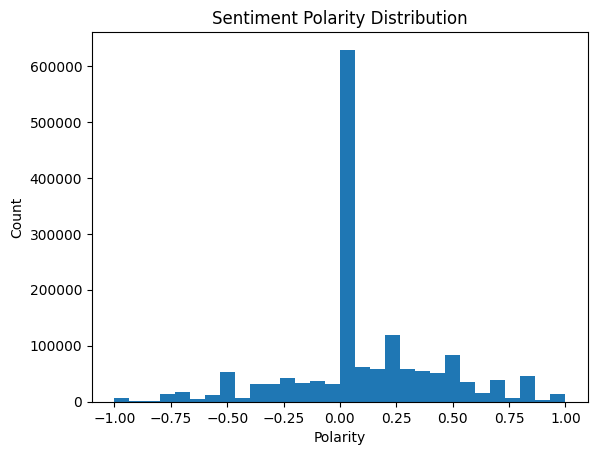

In [37]:
plt.hist(df['polarity'], bins=30)

plt.xlabel("Polarity")

plt.ylabel("Count")

plt.title("Sentiment Polarity Distribution")

plt.show()

In [38]:
df['polarity'].describe()

count    1.599999e+06
mean     9.169613e-02
std      3.357164e-01
min     -1.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.750000e-01
max      1.000000e+00
Name: polarity, dtype: float64

In [39]:
positive = df[df['polarity'] > 0]

negative = df[df['polarity'] < 0]

neutral = df[df['polarity'] == 0]

print("Positive Tweets :", positive.shape[0])

print("Negative Tweets :", negative.shape[0])

print("Neutral Tweets :", neutral.shape[0])

Positive Tweets : 678127
Negative Tweets : 323298
Neutral Tweets : 598574


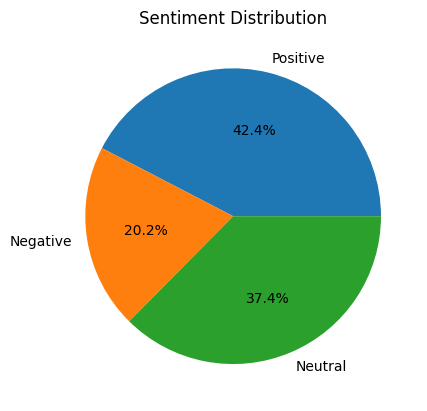

In [40]:
labels = ['Positive', 'Negative', 'Neutral']

sizes = [
    positive.shape[0],
    negative.shape[0],
    neutral.shape[0]
]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title("Sentiment Distribution")

plt.show()

In [41]:
positive[['clean_tweet', 'polarity']].head(10)

,clean_tweet,polarity
1,dived many times ball managed save rest go bounds,0.500000
2,whole body feels itchy like fire,0.200000
4,whole crew,0.200000
6,hey long time see yes rains bit bit lol im fin...,0.341667
13,wouldve first didnt gun really though zac snyd...,0.225000
17,ahh ive always wanted see rent love soundtrack,0.500000
19,day didnt get much done,0.200000
27,ooooh lol leslie ok wont leslie wont get mad,0.225000
29,hacked account aim make new one,0.136364
32,awe love miss,0.500000


In [42]:
sample_tweets = df[['clean_tweet', 'polarity']].sample(20)

sample_tweets

,clean_tweet,polarity
212084,baby wont take nap come kid need shower,0.000000
810776,amazed happy ive since saturday must sun figur...,0.150000
1409493,im curious one youll shouldersurf give afterac...,-0.100000
517294,half day busy afternoon evening,-0.033333
1288377,luv look,0.000000
1133707,camera awesome,1.000000
1310402,looking stevens wedding pictures feel like im ...,0.000000
283987,mines aswell,0.000000
1387912,thank lovely walk happy weekend,0.650000
344332,weather crap today,-0.800000


In [44]:
df.to_csv("cleaned_sentiment_data.csv", index=False)

In [47]:
df['sentiment_label'] = df['polarity'].apply(
    lambda x:
    'Positive' if x > 0
    else (
        'Negative' if x < 0
        else 'Neutral'
    )
)

In [48]:
final_df = df[
    [
        'tweet',
        'clean_tweet',
        'polarity',
        'sentiment_label'
    ]
]

final_df.to_csv(
    'reports/final_sentiment_data.csv',
    index=False
)

print("CSV Saved Successfully")

CSV Saved Successfully
